# Задание 6. Вариант 6
**Выполнил:** Руденко Андрей
**Группа:** МГ-513

**Вариант 6: Planets (экзопланеты)**  
**• Источник:** sns.load_dataset('planets')  
**• Особенности данных:** Пропуски в столбцах mass, distance.

**Общие требования для всех вариантов:**  
1. Загрузить указанный датасет.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)

# Стиль графиков
sns.set(style='whitegrid')

df = sns.load_dataset('planets')

2. Выполнить все 5 этапов: Discover → Structure → Clean → Enrich → Validate.

In [4]:
print("Размер датасета:", df.shape)

df.head()

df.info()

df.describe(include='all')

df.isnull().sum()

df.duplicated().sum()

Размер датасета: (1035, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 48.6+ KB


np.int64(4)

**Вывод после первичного анализа**  
В ходе первичного анализа были выявлены следующие проблемы:
- В столбцах mass и distance присутствуют пропущенные значения.
- Возможны выбросы в числовых признаках:
1) orbital_period
2) mass
3) distance
- Необходимо проверить наличие отрицательных значений orbital_period.
- Требуется удалить дубликаты.
- Датасет содержит как числовые, так и категориальные признаки.

In [7]:
df = df.rename(columns={
    'orbital_period': 'orbital_period_days',
    'number': 'planet_count'
})

df.dtypes

df['year'] = df['year'].astype(int)
df['planet_count'] = df['planet_count'].astype(int)

**Структурирование данных**  
На этапе структурирования были выполнены:  
- Переименование столбцов для улучшения читаемости;  
- Приведение числовых признаков к корректным типам данных.

1. Заполнить пропуски в mass медианой по методу обнаружения
(method).

In [8]:
df['mass'] = df.groupby('method')['mass'].transform(
    lambda x: x.fillna(x.median())
)

df['mass'].isnull().sum()

np.int64(76)

2. Заполнить пропуски в distance медианой по году открытия.


In [9]:
df['distance'] = df.groupby('year')['distance'].transform(
    lambda x: x.fillna(x.median())
)

df['distance'] = df['distance'].fillna(df['distance'].median())

4. Удалить строки, где orbital_period < 0.


In [11]:
(df['orbital_period_days'] < 0).sum()

df = df[df['orbital_period_days'] >= 0]

5. Удалить дубликаты.


In [12]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Дубликатов до удаления:", duplicates_before)
print("Дубликатов после удаления:", duplicates_after)

Дубликатов до удаления: 0
Дубликатов после удаления: 0


In [13]:
Q1 = df['orbital_period_days'].quantile(0.25)
Q3 = df['orbital_period_days'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['orbital_period_days'] < lower) |
    (df['orbital_period_days'] > upper)
]

print("Количество выбросов:", len(outliers))
print("Нижняя граница:", lower)
print("Верхняя граница:", upper)

Количество выбросов: 126
Нижняя граница: -775.4011487500002
Верхняя граница: 1306.84868925


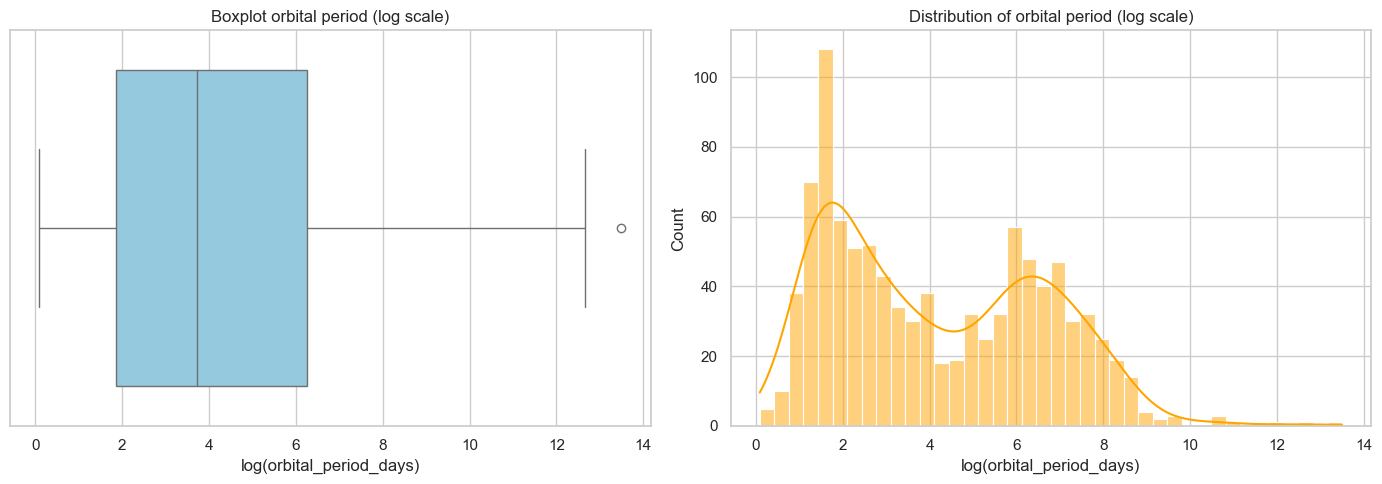

In [23]:
plt.figure(figsize=(14,5))

# Boxplot
plt.subplot(1,2,1)

sns.boxplot(
    x=np.log1p(df['orbital_period_days']),
    color='skyblue'
)

plt.title('Boxplot orbital period (log scale)')
plt.xlabel('log(orbital_period_days)')


# Histogram
plt.subplot(1,2,2)

sns.histplot(
    np.log1p(df['orbital_period_days']),
    bins=40,
    kde=True,
    color='orange'
)

plt.title('Distribution of orbital period (log scale)')
plt.xlabel('log(orbital_period_days)')

plt.tight_layout()
plt.show()

**Анализ распределения orbital_period_days**  
Гистограмма показала, что распределение признака сильно асимметрично и содержит большие выбросы. Для улучшения визуализации была использована логарифмическая шкала.

**Обработка выбросов**  
Для поиска выбросов использовался метод межквартильного размаха (IQR).  
Были обнаружены аномально большие значения orbital_period_days.  
В рамках данной работы выбросы решено оставить, так как они могут отражать реальные астрономические наблюдения.  

3. Создать минимум 2 новых признака.
3. Создать признак discovery_decade (1990-е, 2000-е, 2010-е).

In [15]:
def get_decade(year):
    if year < 2000:
        return '1990s'
    elif year < 2010:
        return '2000s'
    else:
        return '2010s'

df['discovery_decade'] = df['year'].apply(get_decade)

df['distance_category'] = pd.cut(
    df['distance'],
    bins=[0, 50, 200, 1000, np.inf],
    labels=['near', 'medium', 'far', 'very_far']
)

df['mass_category'] = df['mass'].apply(
    lambda x: 'light' if x < 1 else 'heavy'
)

df.head()

,method,planet_count,orbital_period_days,mass,distance,year,discovery_decade,distance_category,mass_category
0,Radial Velocity,1,269.300,7.10,77.40,2006,2000s,medium,heavy
1,Radial Velocity,1,874.774,2.21,56.95,2008,2000s,medium,heavy
2,Radial Velocity,1,763.000,2.60,19.84,2011,2010s,near,heavy
3,Radial Velocity,1,326.030,19.40,110.62,2007,2000s,medium,heavy
4,Radial Velocity,1,516.220,10.50,119.47,2009,2000s,medium,heavy


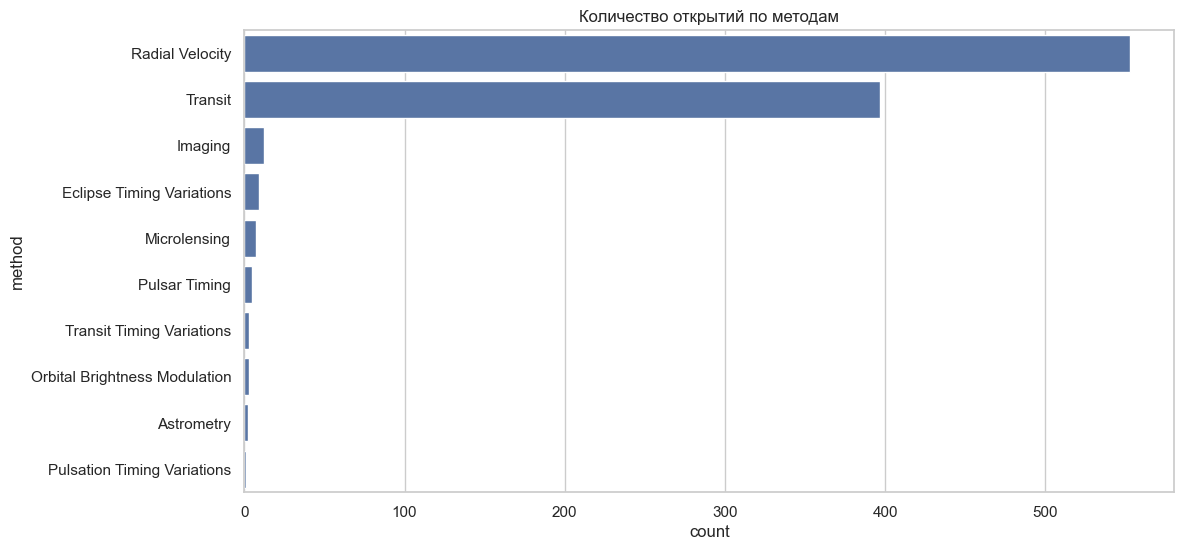

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='method',
    order=df['method'].value_counts().index
)

plt.title('Количество открытий по методам')
plt.show()

**Анализ методов обнаружения**  
Наибольшее количество экзопланет обнаружено методом Radial Velocity, что может быть связано с высокой эффективностью данного метода в ранние годы исследований.

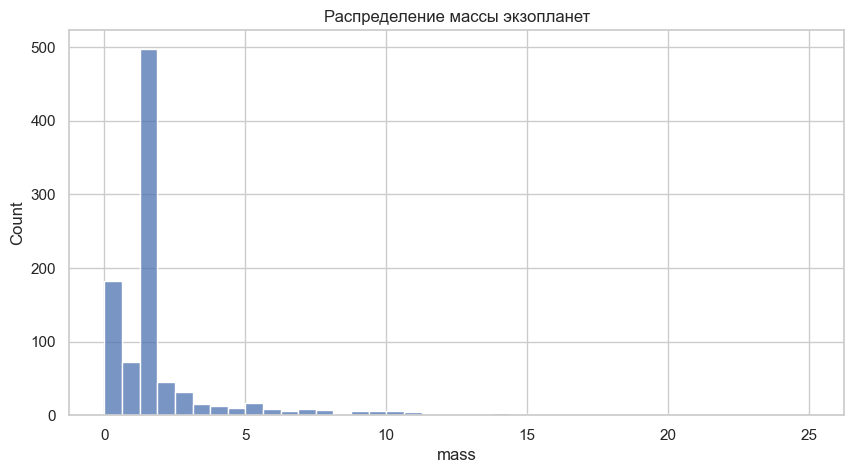

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df['mass'], bins=40)

plt.title('Распределение массы экзопланет')
plt.show()

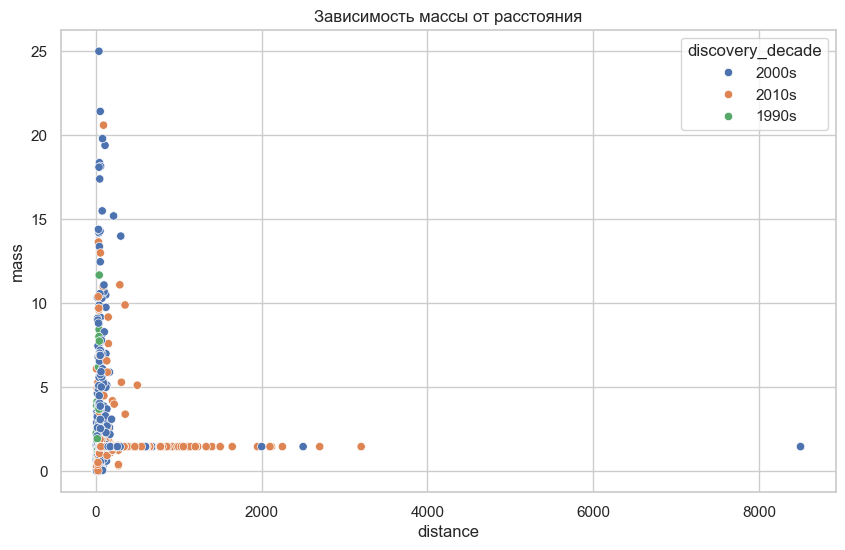

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='distance',
    y='mass',
    hue='discovery_decade'
)

plt.title('Зависимость массы от расстояния')
plt.show()

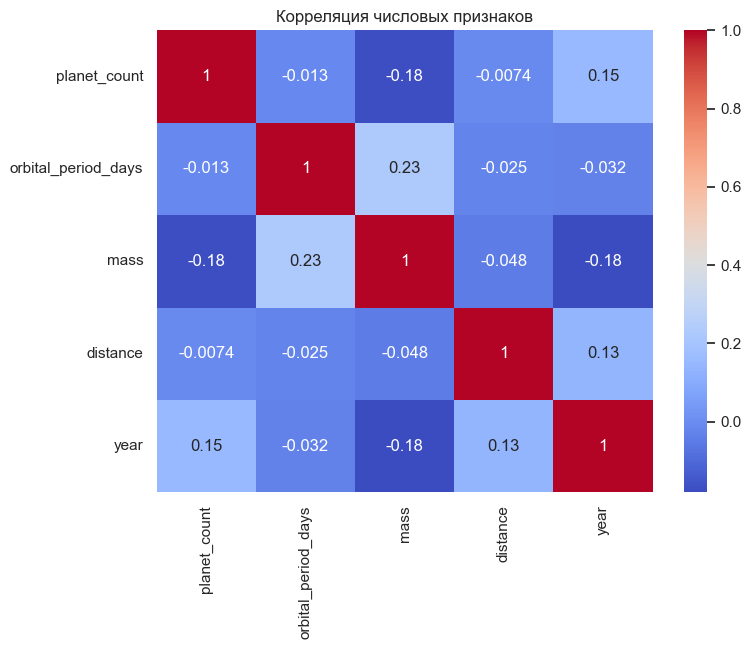

In [19]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Корреляция числовых признаков')
plt.show()

**Анализ корреляций**  
Тепловая карта показала слабую корреляцию между большинством признаков, что говорит о сложной природе астрономических данных.

In [20]:
df.isnull().sum()

print("Минимальный orbital_period_days:",
      df['orbital_period_days'].min())

print("Минимальная mass:",
      df['mass'].min())

print("Минимальная distance:",
      df['distance'].min())

df['discovery_decade'].unique()

Минимальный orbital_period_days: 0.09070629
Минимальная mass: 0.0036
Минимальная distance: 1.35


array(['2000s', '2010s', '1990s'], dtype=object)

4. Сохранить очищенный датасет в файл cleaned_название_датасета.csv.


In [22]:
df.to_csv('cleaned_planets.csv', index=False)

print("Файл cleaned_planets.csv успешно сохранён")

Файл cleaned_planets.csv успешно сохранён


**Основные результаты анализа**  
В ходе работы был проведён полный цикл EDA для датасета Planets.  
Были выполнены следующие этапы:  
- Проведён первичный анализ структуры данных;  
- Обнаружены и обработаны пропущенные значения;  
- Удалены дубликаты;  
- Проверены выбросы методом IQR;  
- Созданы новые признаки:  
- discovery_decade  
- distance_category  
- mass_category  
- Выполнена визуализация распределений и взаимосвязей.  
**Основные наблюдения**  
- Наиболее популярным методом обнаружения экзопланет является Radial Velocity.  
- Большинство экзопланет были открыты после 2000 года.  
- В данных присутствуют значительные выбросы по orbital_period_days.  
- Между некоторыми числовыми признаками наблюдается слабая корреляция.  
**Возможные гипотезы**  
- Более современные методы позволяют обнаруживать планеты на больших расстояниях.
- Планеты большой массы обнаруживаются чаще из-за ограничений методов наблюдения.